In [9]:
import os
import gc
import h5py
import numpy as np
from tqdm import tqdm

H5_PATH = r"D:\rice_correlacion_vectorizada.h5"
OUT_DIR = r"D:\rice_som_k6"
os.makedirs(OUT_DIR, exist_ok=True)

BATCH_SIZE = 4  # pequeño para máxima estabilidad

def flatten_batch(batch_3d):
    return batch_3d.reshape(batch_3d.shape[0], -1).astype(np.float32)

def clean_nans(X):
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

with h5py.File(H5_PATH, "r") as f:
    n_pix, n_months, n_ocean = f["correlacion"].shape

flattened_dim = n_months * n_ocean

global_sum = np.zeros(flattened_dim, dtype=np.float64)
global_count = 0

for i0 in tqdm(range(0, n_pix, BATCH_SIZE), desc="Media global"):
    i1 = min(i0 + BATCH_SIZE, n_pix)

    with h5py.File(H5_PATH, "r") as f:
        Xb = f["correlacion"][i0:i1]

    Xb = flatten_batch(Xb)
    Xb = clean_nans(Xb)

    global_sum += Xb.sum(axis=0, dtype=np.float64)
    global_count += Xb.shape[0]

    del Xb
    gc.collect()

global_mean = global_sum / global_count
np.save(os.path.join(OUT_DIR, "global_mean.npy"), global_mean)

print("✅ global_mean guardada")
print(global_mean.shape)

Media global: 100%|██████████████████████████████████████████████████████████████████| 797/797 [10:20<00:00,  1.28it/s]

✅ global_mean guardada
(3110400,)


In [13]:
import os
import gc
import time
import h5py
import numpy as np
from tqdm import tqdm
from sklearn.decomposition import IncrementalPCA

# ============================================================
# RUTAS NUEVAS (LOCAL EN TU PC)
# ============================================================

H5_PATH = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_correlacion_vectorizada.h5"
OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# PARÁMETROS
# ============================================================

N_PCA = 30
TARGET_BATCH = 32
RETRIES = 3
SLEEP_SEC = 0.2

# ============================================================
# FUNCIONES
# ============================================================

def flatten_one(sample_3d):
    """
    sample_3d: (12, 259200)
    salida:    (3110400,)
    """
    return sample_3d.reshape(-1).astype(np.float32)

def clean_nans(x):
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

def safe_read_one(h5_path, idx, retries=3, sleep_sec=0.2):
    """
    Lee un solo píxel agrícola del H5 con reintentos.
    """
    last_err = None
    for _ in range(retries):
        try:
            with h5py.File(h5_path, "r") as f:
                x = f["correlacion"][idx]
            return x
        except Exception as e:
            last_err = e
            time.sleep(sleep_sec)
    raise last_err

# ============================================================
# CARGAR MEDIA GLOBAL
# ============================================================

global_mean_path = os.path.join(OUT_DIR, "global_mean.npy")
if not os.path.exists(global_mean_path):
    raise FileNotFoundError(
        f"No encontré global_mean.npy en:\n{global_mean_path}\n"
        "Primero debes correr la Etapa A con esta misma carpeta OUT_DIR."
    )

global_mean = np.load(global_mean_path)

# ============================================================
# LEER METADATOS DEL H5
# ============================================================

with h5py.File(H5_PATH, "r") as f:
    n_pix, n_months, n_ocean = f["correlacion"].shape

print("=== ETAPA B ROBUSTA: AJUSTE DE INCREMENTAL PCA ===")
print(f"n_pix         : {n_pix}")
print(f"n_months      : {n_months}")
print(f"n_ocean       : {n_ocean}")
print(f"N_PCA         : {N_PCA}")
print(f"TARGET_BATCH  : {TARGET_BATCH}")
print(f"flattened_dim : {n_months * n_ocean:,}")
print(f"H5_PATH       : {H5_PATH}")
print(f"OUT_DIR       : {OUT_DIR}")

if TARGET_BATCH < N_PCA:
    raise ValueError(f"TARGET_BATCH ({TARGET_BATCH}) debe ser >= N_PCA ({N_PCA})")

# ============================================================
# AJUSTAR IPCA
# ============================================================

ipca = IncrementalPCA(n_components=N_PCA)

failed_indices = []
buffer_rows = []
fit_calls = 0

for idx in tqdm(range(n_pix), desc="Lectura 1x1 + IPCA"):
    try:
        x = safe_read_one(H5_PATH, idx, retries=RETRIES, sleep_sec=SLEEP_SEC)
        x = flatten_one(x)
        x = clean_nans(x)
        x = x - global_mean
        buffer_rows.append(x)

        if len(buffer_rows) >= TARGET_BATCH:
            X_batch = np.vstack(buffer_rows).astype(np.float32)

            if X_batch.shape[0] >= N_PCA:
                ipca.partial_fit(X_batch)
                fit_calls += 1

            del X_batch
            buffer_rows = []
            gc.collect()

    except Exception as e:
        print(f"\n⚠️ Error en índice {idx} -> {repr(e)}")
        failed_indices.append((idx, repr(e)))

# ============================================================
# PROCESAR REMANENTE
# ============================================================

if len(buffer_rows) >= N_PCA:
    X_batch = np.vstack(buffer_rows).astype(np.float32)
    ipca.partial_fit(X_batch)
    fit_calls += 1
    del X_batch
    gc.collect()
else:
    print(f"\n⚠️ Remanente descartado: {len(buffer_rows)} muestras (< N_PCA={N_PCA})")

# ============================================================
# GUARDAR PCA
# ============================================================

np.save(os.path.join(OUT_DIR, "ipca_components.npy"), ipca.components_)
np.save(os.path.join(OUT_DIR, "ipca_mean.npy"), ipca.mean_)
np.save(os.path.join(OUT_DIR, "ipca_explained_variance_ratio.npy"), ipca.explained_variance_ratio_)
np.save(os.path.join(OUT_DIR, "ipca_singular_values.npy"), ipca.singular_values_)
np.save(os.path.join(OUT_DIR, "ipca_explained_variance.npy"), ipca.explained_variance_)

# guardar índices fallidos
np.save(os.path.join(OUT_DIR, "ipca_failed_indices.npy"), np.array(failed_indices, dtype=object))

# ============================================================
# REPORTE FINAL
# ============================================================

print("\n✅ PCA ajustado y guardado")
print(f"partial_fit calls: {fit_calls}")
print("Varianza explicada acumulada:", float(ipca.explained_variance_ratio_.sum()))
print("Primeras 10 razones de varianza explicada:")
print(np.round(ipca.explained_variance_ratio_[:10], 6))

if failed_indices:
    print(f"\n⚠️ Índices fallidos: {len(failed_indices)}")
    print("Primeros 10:")
    for item in failed_indices[:10]:
        print(item)
else:
    print("\n✅ Sin índices fallidos")

=== ETAPA B ROBUSTA: AJUSTE DE INCREMENTAL PCA ===
n_pix         : 3186
n_months      : 12
n_ocean       : 259200
N_PCA         : 30
TARGET_BATCH  : 32
flattened_dim : 3,110,400
H5_PATH       : C:\Users\paola\Tesis\CORRELA_TODOS\rice_correlacion_vectorizada.h5
OUT_DIR       : C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6


Lectura 1x1 + IPCA: 100%|████████████████████████████████████████████████████████| 3186/3186 [5:42:59<00:00,  6.46s/it]



⚠️ Remanente descartado: 18 muestras (< N_PCA=30)

✅ PCA ajustado y guardado
partial_fit calls: 99
Varianza explicada acumulada: 0.9793218019935997
Primeras 10 razones de varianza explicada:
[0.237018 0.121623 0.088271 0.062711 0.057171 0.047704 0.041305 0.032794
 0.030169 0.028132]

✅ Sin índices fallidos


In [14]:
import os

p = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_correlacion_vectorizada.h5"

print("Existe:", os.path.exists(p))
print("Es archivo:", os.path.isfile(p))
print("Tamaño bytes:", os.path.getsize(p))
print("Ruta absoluta:", os.path.abspath(p))

Existe: True
Es archivo: True
Tamaño bytes: 25282967504
Ruta absoluta: C:\Users\paola\Tesis\CORRELA_TODOS\rice_correlacion_vectorizada.h5


In [16]:
import os
import gc
import time
import h5py
import numpy as np
from tqdm import tqdm

# ============================================================
# RUTAS
# ============================================================

H5_PATH = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_correlacion_vectorizada.h5"
OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

# ============================================================
# PARÁMETROS
# ============================================================

RETRIES = 3
SLEEP_SEC = 0.2

# ============================================================
# FUNCIONES
# ============================================================

def flatten_one(sample_3d):
    return sample_3d.reshape(-1).astype(np.float32)

def clean_nans(x):
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

def safe_read_one(h5_path, idx, retries=3, sleep_sec=0.2):
    last_err = None
    for _ in range(retries):
        try:
            with h5py.File(h5_path, "r") as f:
                x = f["correlacion"][idx]
            return x
        except Exception as e:
            last_err = e
            time.sleep(sleep_sec)
    raise last_err

# ============================================================
# CARGAR PARÁMETROS DEL PCA
# ============================================================

global_mean = np.load(os.path.join(OUT_DIR, "global_mean.npy"))          # (3110400,)
components  = np.load(os.path.join(OUT_DIR, "ipca_components.npy"))      # (N_PCA, 3110400)
ipca_mean   = np.load(os.path.join(OUT_DIR, "ipca_mean.npy"))            # (3110400,)

N_PCA = components.shape[0]

# ============================================================
# METADATOS DEL H5
# ============================================================

with h5py.File(H5_PATH, "r") as f:
    n_pix, n_months, n_ocean = f["correlacion"].shape
    lat_idx = f["lat_idx"][:]
    lon_idx = f["lon_idx"][:]

print("=== ETAPA C CORREGIDA: TRANSFORMACIÓN AL ESPACIO PCA ===")
print(f"n_pix         : {n_pix}")
print(f"n_months      : {n_months}")
print(f"n_ocean       : {n_ocean}")
print(f"N_PCA         : {N_PCA}")
print(f"flattened_dim : {n_months * n_ocean:,}")
print(f"H5_PATH       : {H5_PATH}")
print(f"OUT_DIR       : {OUT_DIR}")

# ============================================================
# TRANSFORMACIÓN MANUAL
# sklearn haría algo equivalente a:
# X_pca = (X_centered - ipca.mean_) @ components.T
# donde X_centered = X - global_mean
# ============================================================

X_pca = np.full((n_pix, N_PCA), np.nan, dtype=np.float32)
failed_indices = []

for idx in tqdm(range(n_pix), desc="Transformación PCA 1x1"):
    try:
        x = safe_read_one(H5_PATH, idx, retries=RETRIES, sleep_sec=SLEEP_SEC)
        x = flatten_one(x)
        x = clean_nans(x)

        # mismo preprocesamiento usado en la Etapa B
        x_centered = x - global_mean

        # transformación PCA manual
        xp = (x_centered - ipca_mean) @ components.T   # shape: (N_PCA,)

        X_pca[idx] = xp.astype(np.float32)

        del x, x_centered, xp
        gc.collect()

    except Exception as e:
        print(f"\n⚠️ Error en índice {idx} -> {repr(e)}")
        failed_indices.append((idx, repr(e)))

# ============================================================
# FILTRAR FILAS VÁLIDAS
# ============================================================

valid_rows = ~np.isnan(X_pca).any(axis=1)

X_pca_valid = X_pca[valid_rows]
lat_idx_valid = lat_idx[valid_rows]
lon_idx_valid = lon_idx[valid_rows]
pixel_id_valid = np.arange(n_pix)[valid_rows]

# ============================================================
# GUARDAR SALIDAS
# ============================================================

np.save(os.path.join(OUT_DIR, "X_pca.npy"), X_pca_valid)
np.save(os.path.join(OUT_DIR, "lat_idx_valid.npy"), lat_idx_valid)
np.save(os.path.join(OUT_DIR, "lon_idx_valid.npy"), lon_idx_valid)
np.save(os.path.join(OUT_DIR, "pixel_id_valid.npy"), pixel_id_valid)
np.save(os.path.join(OUT_DIR, "valid_rows_mask.npy"), valid_rows)
np.save(os.path.join(OUT_DIR, "transform_failed_indices.npy"), np.array(failed_indices, dtype=object))

print("\n✅ Transformación PCA terminada")
print(f"X_pca_valid shape: {X_pca_valid.shape}")
print(f"Píxeles válidos  : {X_pca_valid.shape[0]} / {n_pix}")

if failed_indices:
    print(f"\n⚠️ Índices fallidos: {len(failed_indices)}")
    print("Primeros 10:")
    for item in failed_indices[:10]:
        print(item)
else:
    print("\n✅ Sin índices fallidos")

=== ETAPA C CORREGIDA: TRANSFORMACIÓN AL ESPACIO PCA ===
n_pix         : 3186
n_months      : 12
n_ocean       : 259200
N_PCA         : 30
flattened_dim : 3,110,400
H5_PATH       : C:\Users\paola\Tesis\CORRELA_TODOS\rice_correlacion_vectorizada.h5
OUT_DIR       : C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6


Transformación PCA 1x1: 100%|██████████████████████████████████████████████████████| 3186/3186 [25:52<00:00,  2.05it/s]


✅ Transformación PCA terminada
X_pca_valid shape: (3186, 30)
Píxeles válidos  : 3186 / 3186

✅ Sin índices fallidos


In [17]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from minisom import MiniSom

# ============================================================
# RUTAS
# ============================================================

OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

# ============================================================
# PARÁMETROS DEL SOM
# ============================================================

SOM_X = 2
SOM_Y = 3
K = SOM_X * SOM_Y

SIGMA = 1.0
LEARNING_RATE = 0.5
SOM_ITERS = 20000
RANDOM_SEED = 42

# ============================================================
# CARGAR DATOS PCA
# ============================================================

X_pca = np.load(os.path.join(OUT_DIR, "X_pca.npy"))
lat_idx = np.load(os.path.join(OUT_DIR, "lat_idx_valid.npy"))
lon_idx = np.load(os.path.join(OUT_DIR, "lon_idx_valid.npy"))
pixel_id = np.load(os.path.join(OUT_DIR, "pixel_id_valid.npy"))

print("=== ETAPA D: SOM ===")
print(f"X_pca shape : {X_pca.shape}")
print(f"SOM grid    : {SOM_X} x {SOM_Y}")
print(f"k           : {K}")
print(f"iters       : {SOM_ITERS}")

# ============================================================
# FUNCIÓN DE ERROR DE CUANTIZACIÓN
# ============================================================

def quantization_error(som, X):
    err = 0.0
    for x in X:
        w = som.winner(x)
        err += np.linalg.norm(x - som.get_weights()[w])
    return err / len(X)

# ============================================================
# ENTRENAR SOM
# ============================================================

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_pca.shape[1],
    sigma=SIGMA,
    learning_rate=LEARNING_RATE,
    neighborhood_function="gaussian",
    random_seed=RANDOM_SEED
)

som.pca_weights_init(X_pca)
som.train_random(X_pca, SOM_ITERS, verbose=True)

qe = quantization_error(som, X_pca)
weights = som.get_weights()

print("\n✅ SOM entrenado")
print(f"Quantization error: {qe:.6f}")

# ============================================================
# ASIGNAR BMU / CLASE A CADA PÍXEL
# ============================================================

winners = np.zeros((X_pca.shape[0], 2), dtype=np.int32)
labels = np.zeros(X_pca.shape[0], dtype=np.int32)

for i in tqdm(range(X_pca.shape[0]), desc="Asignación SOM"):
    wx, wy = som.winner(X_pca[i])
    winners[i] = [wx, wy]
    labels[i] = wx * SOM_Y + wy

# ============================================================
# GUARDAR ASIGNACIONES
# ============================================================

df_assign = pd.DataFrame({
    "pixel_id": pixel_id,
    "lat_idx": lat_idx,
    "lon_idx": lon_idx,
    "som_x": winners[:, 0],
    "som_y": winners[:, 1],
    "label": labels
})

df_assign.to_csv(os.path.join(OUT_DIR, "som_assignments.csv"), index=False)

# ============================================================
# FRECUENCIA POR CLASE
# ============================================================

class_counts = pd.Series(labels).value_counts().sort_index()
df_counts = pd.DataFrame({
    "label": class_counts.index,
    "count": class_counts.values,
    "fraction": class_counts.values / len(labels)
})

df_counts.to_csv(os.path.join(OUT_DIR, "som_class_frequencies.csv"), index=False)

print("\n=== FRECUENCIA POR CLASE ===")
print(df_counts)

# ============================================================
# GUARDAR PESOS DEL SOM
# ============================================================

np.savez_compressed(
    os.path.join(OUT_DIR, "som_weights.npz"),
    weights=weights,
    quantization_error=np.array([qe], dtype=np.float32)
)

# ============================================================
# FIGURA 1: FRECUENCIA DE CLASES
# ============================================================

plt.figure(figsize=(8, 4))
plt.bar(df_counts["label"], df_counts["count"])
plt.xlabel("Clase SOM")
plt.ylabel("Número de píxeles")
plt.title("Frecuencia de clases SOM (k=6)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "som_class_counts.png"), dpi=180)
plt.close()

# ============================================================
# FIGURA 2: DISPERSIÓN EN PC1-PC2
# ============================================================

plt.figure(figsize=(8, 6))
for label in range(K):
    mask = labels == label
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=10,
        alpha=0.45,
        label=f"Clase {label}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("SOM sobre espacio PCA")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "som_pca_scatter.png"), dpi=180)
plt.close()

# ============================================================
# FIGURA 3: U-MATRIX
# ============================================================

u_matrix = som.distance_map()

plt.figure(figsize=(6, 5))
plt.imshow(u_matrix.T, origin="lower", aspect="auto")
plt.colorbar(label="Distancia vecinal (U-Matrix)")
plt.xticks(range(SOM_X))
plt.yticks(range(SOM_Y))
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.title("U-Matrix del SOM")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "som_umatrix.png"), dpi=180)
plt.close()

# ============================================================
# METADATOS
# ============================================================

meta = {
    "X_pca_shape": list(X_pca.shape),
    "som_x": SOM_X,
    "som_y": SOM_Y,
    "k": K,
    "sigma": SIGMA,
    "learning_rate": LEARNING_RATE,
    "som_iters": SOM_ITERS,
    "random_seed": RANDOM_SEED,
    "quantization_error": float(qe)
}

with open(os.path.join(OUT_DIR, "som_run_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("\n✅ ETAPA D terminada")
print(f"Resultados guardados en:\n{OUT_DIR}")

=== ETAPA D: SOM ===
X_pca shape : (3186, 30)
SOM grid    : 2 x 3
k           : 6
iters       : 20000
 [ 20000 / 20000 ] 100% - 0:00:00 left 
 quantization error: 103.52900799004063

✅ SOM entrenado
Quantization error: 103.529008


Asignación SOM: 100%|███████████████████████████████████████████████████████████| 3186/3186 [00:00<00:00, 53448.36it/s]



=== FRECUENCIA POR CLASE ===
   label  count  fraction
0      0    503  0.157878
1      1    716  0.224733
2      2    528  0.165725
3      3    305  0.095731
4      4    707  0.221908
5      5    427  0.134024

✅ ETAPA D terminada
Resultados guardados en:
C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6


In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# RUTAS
# ============================================================

OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

# ============================================================
# CARGAR INSUMOS
# ============================================================

som_data = np.load(os.path.join(OUT_DIR, "som_weights.npz"))
weights = som_data["weights"]   # (2, 3, 30)

components = np.load(os.path.join(OUT_DIR, "ipca_components.npy"))   # (30, 3110400)
ipca_mean = np.load(os.path.join(OUT_DIR, "ipca_mean.npy"))          # (3110400,)
global_mean = np.load(os.path.join(OUT_DIR, "global_mean.npy"))      # (3110400,)

df_assign = pd.read_csv(os.path.join(OUT_DIR, "som_assignments.csv"))

SOM_X, SOM_Y, N_PCA = weights.shape
K = SOM_X * SOM_Y
N_MONTHS = 12
N_OCEAN = components.shape[1] // N_MONTHS

print("=== ETAPA E: RECONSTRUCCIÓN DE PROTOTIPOS ===")
print(f"SOM shape     : {weights.shape}")
print(f"K             : {K}")
print(f"N_MONTHS      : {N_MONTHS}")
print(f"N_OCEAN       : {N_OCEAN}")

# ============================================================
# FUNCIONES
# ============================================================

def reconstruct_from_pca(code_pca, components, ipca_mean, global_mean):
    """
    Reconstrucción manual:
    x_centered ≈ code_pca @ components + ipca_mean
    x_original ≈ x_centered + global_mean
    """
    x_centered = code_pca @ components + ipca_mean
    x_original = x_centered + global_mean
    return x_original.astype(np.float32)

def summarize_monthly_signature(proto_vec, n_months=12):
    arr = proto_vec.reshape(n_months, -1)
    return {
        "monthly_mean": arr.mean(axis=1),
        "monthly_max": arr.max(axis=1),
        "monthly_min": arr.min(axis=1),
        "monthly_std": arr.std(axis=1),
    }

def plot_monthly_summary(monthly_dict, title, save_path):
    months = np.arange(1, 13)

    plt.figure(figsize=(10, 5))
    plt.plot(months, monthly_dict["monthly_mean"], marker="o", label="mean")
    plt.plot(months, monthly_dict["monthly_max"], marker="^", label="max")
    plt.plot(months, monthly_dict["monthly_min"], marker="v", label="min")
    plt.fill_between(
        months,
        monthly_dict["monthly_mean"] - monthly_dict["monthly_std"],
        monthly_dict["monthly_mean"] + monthly_dict["monthly_std"],
        alpha=0.2,
        label="mean ± std"
    )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(months)
    plt.xlabel("Mes")
    plt.ylabel("Correlación reconstruida")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.close()

# ============================================================
# RECONSTRUIR PROTOTIPOS
# ============================================================

proto_pca = np.zeros((K, N_PCA), dtype=np.float32)
proto_original = np.zeros((K, components.shape[1]), dtype=np.float32)

k = 0
for ix in range(SOM_X):
    for iy in range(SOM_Y):
        code_pca = weights[ix, iy]
        proto_pca[k] = code_pca.astype(np.float32)
        proto_original[k] = reconstruct_from_pca(code_pca, components, ipca_mean, global_mean)
        k += 1

np.savez_compressed(
    os.path.join(OUT_DIR, "som_codebooks_and_prototypes.npz"),
    proto_pca=proto_pca,
    proto_original=proto_original
)

# ============================================================
# RESUMEN POR CLASE
# ============================================================

summary_rows = []

for label in range(K):
    proto_vec = proto_original[label]
    monthly = summarize_monthly_signature(proto_vec, n_months=N_MONTHS)

    count = int((df_assign["label"] == label).sum())
    fraction = float((df_assign["label"] == label).mean())

    row = {
        "label": label,
        "count": count,
        "fraction": fraction
    }

    for m in range(N_MONTHS):
        row[f"month_{m+1:02d}_mean"] = float(monthly["monthly_mean"][m])
        row[f"month_{m+1:02d}_max"]  = float(monthly["monthly_max"][m])
        row[f"month_{m+1:02d}_min"]  = float(monthly["monthly_min"][m])
        row[f"month_{m+1:02d}_std"]  = float(monthly["monthly_std"][m])

    summary_rows.append(row)

    plot_monthly_summary(
        monthly,
        title=f"Clase SOM {label} — resumen mensual del prototipo",
        save_path=os.path.join(OUT_DIR, f"som_class_{label}_monthly_summary.png")
    )

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(os.path.join(OUT_DIR, "som_class_summary.csv"), index=False)

# ============================================================
# REPORTE FINAL
# ============================================================

print("\n✅ ETAPA E terminada")
print("Archivo resumen:", os.path.join(OUT_DIR, "som_class_summary.csv"))
print("Archivo prototipos:", os.path.join(OUT_DIR, "som_codebooks_and_prototypes.npz"))
print("\nResumen rápido:")
print(df_summary[["label", "count", "fraction"]])

=== ETAPA E: RECONSTRUCCIÓN DE PROTOTIPOS ===
SOM shape     : (2, 3, 30)
K             : 6
N_MONTHS      : 12
N_OCEAN       : 259200

✅ ETAPA E terminada
Archivo resumen: C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6\som_class_summary.csv
Archivo prototipos: C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6\som_codebooks_and_prototypes.npz

Resumen rápido:
   label  count  fraction
0      0    503  0.157878
1      1    716  0.224733
2      2    528  0.165725
3      3    305  0.095731
4      4    707  0.221908
5      5    427  0.134024


In [19]:
som_class_summary.csv

NameError: name 'som_class_summary' is not defined

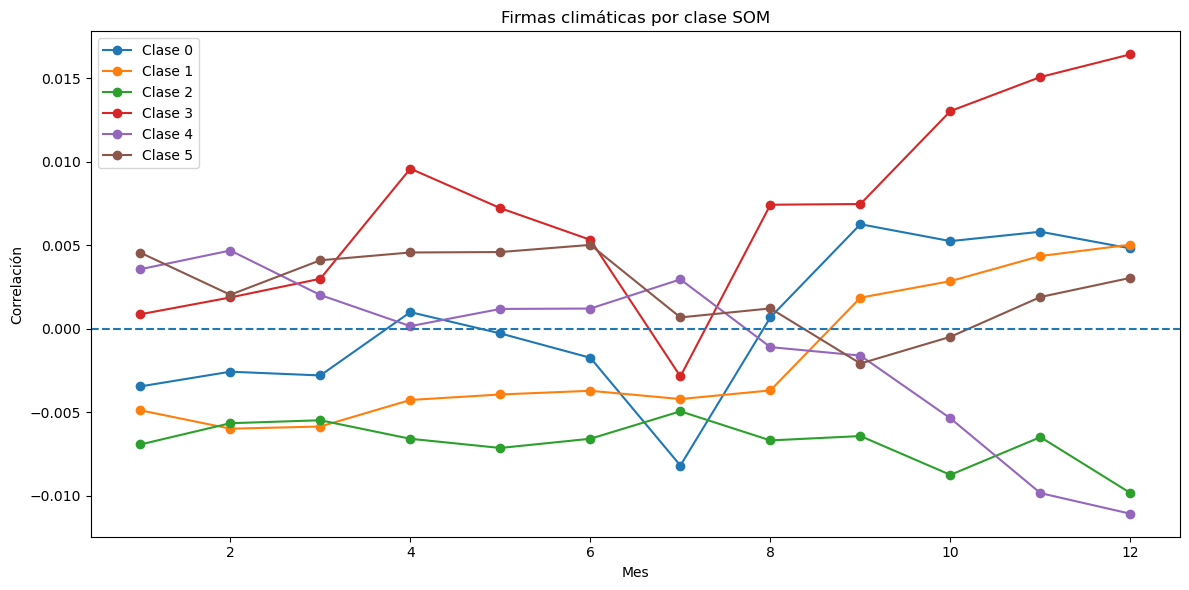

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

df = pd.read_csv(os.path.join(OUT_DIR, "som_class_summary.csv"))

months = np.arange(1, 13)

plt.figure(figsize=(12,6))

for _, row in df.iterrows():
    means = [row[f"month_{m:02d}_mean"] for m in months]
    plt.plot(months, means, marker="o", label=f"Clase {int(row['label'])}")

plt.axhline(0, linestyle="--")
plt.xlabel("Mes")
plt.ylabel("Correlación")
plt.title("Firmas climáticas por clase SOM")
plt.legend()
plt.tight_layout()
plt.show()

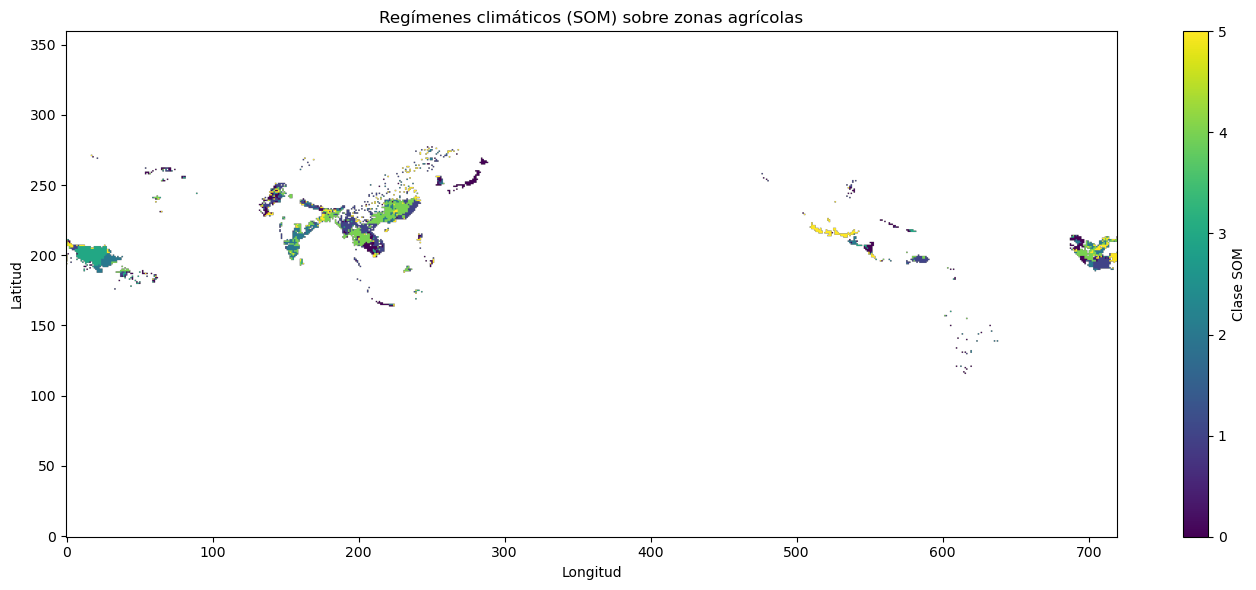

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# RUTAS
# ============================================================

OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

# ============================================================
# CARGAR DATOS
# ============================================================

df = pd.read_csv(f"{OUT_DIR}\\som_assignments.csv")

lat_idx = df["lat_idx"].values
lon_idx = df["lon_idx"].values
labels  = df["label"].values

# grid global original
n_lat = 360
n_lon = 720

# inicializar mapa vacío
map_som = np.full((n_lat, n_lon), np.nan)

# llenar mapa
for i in range(len(labels)):
    map_som[lat_idx[i], lon_idx[i]] = labels[i]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14,6))

im = plt.imshow(map_som, origin="lower", aspect="auto")

cbar = plt.colorbar(im)
cbar.set_label("Clase SOM")

plt.title("Regímenes climáticos (SOM) sobre zonas agrícolas")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.tight_layout()
plt.show()

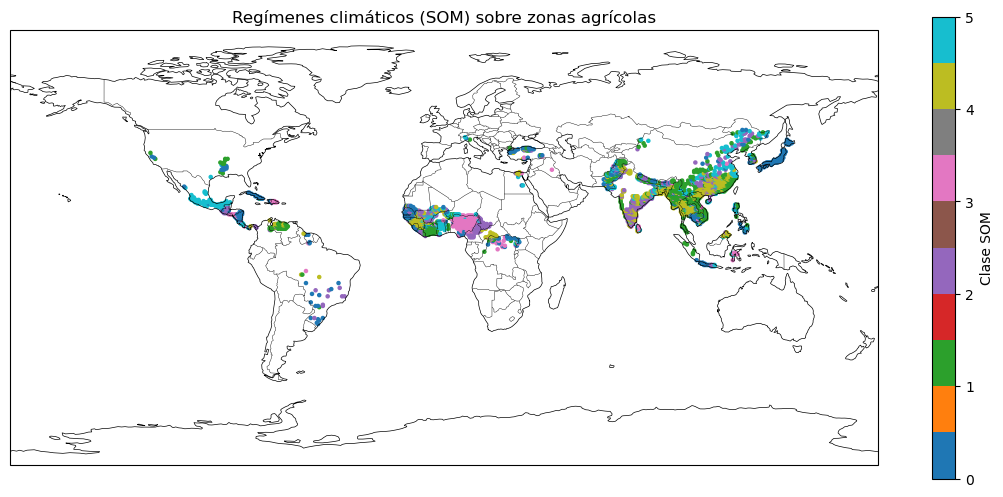

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# RUTAS
# ============================================================

OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

df = pd.read_csv(f"{OUT_DIR}\\som_assignments.csv")

lat_idx = df["lat_idx"].values
lon_idx = df["lon_idx"].values
labels  = df["label"].values

# ============================================================
# CONVERTIR ÍNDICES A LAT/LON REALES
# ============================================================

lat = -89.75 + lat_idx * 0.5
lon = 0.25 + lon_idx * 0.5

# convertir a [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14,6))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

# mapa base
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# scatter real
sc = ax.scatter(
    lon, lat,
    c=labels,
    s=5,
    cmap="tab10",
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, label="Clase SOM")

plt.title("Regímenes climáticos (SOM) sobre zonas agrícolas")
plt.show()

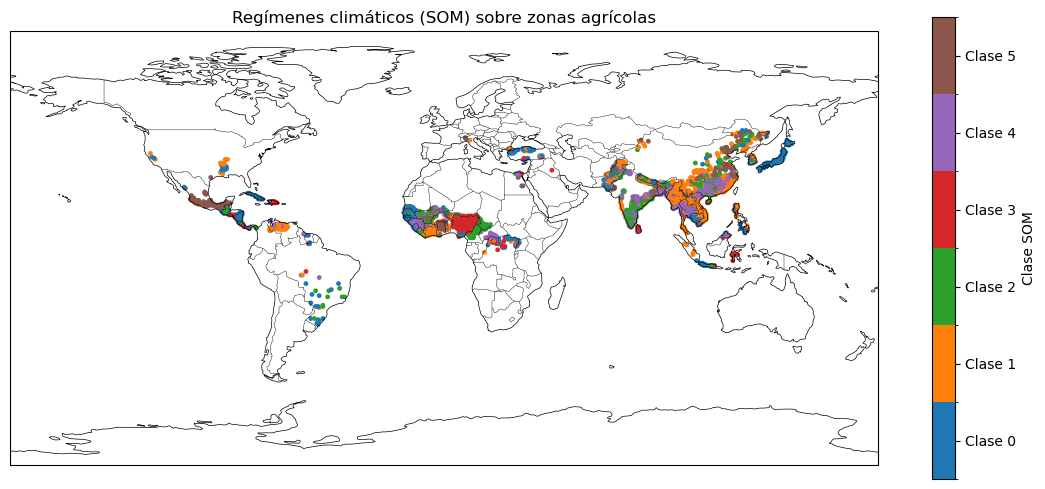

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"

df = pd.read_csv(f"{OUT_DIR}\\som_assignments.csv")

lat_idx = df["lat_idx"].values
lon_idx = df["lon_idx"].values
labels  = df["label"].values

# ============================================================
# CONVERTIR A LAT/LON REAL
# ============================================================

lat = -89.75 + lat_idx * 0.5
lon = 0.25 + lon_idx * 0.5
lon = np.where(lon > 180, lon - 360, lon)

# ============================================================
# COLORMAP DISCRETO (6 COLORES EXACTOS)
# ============================================================

colors = [
    "#1f77b4",  # clase 0
    "#ff7f0e",  # clase 1
    "#2ca02c",  # clase 2
    "#d62728",  # clase 3
    "#9467bd",  # clase 4
    "#8c564b",  # clase 5
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

sc = ax.scatter(
    lon, lat,
    c=labels,
    s=6,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ticks=range(6))
cbar.set_label("Clase SOM")
cbar.set_ticks(range(6))
cbar.set_ticklabels([f"Clase {i}" for i in range(6)])

plt.title("Regímenes climáticos (SOM) sobre zonas agrícolas")
plt.show()

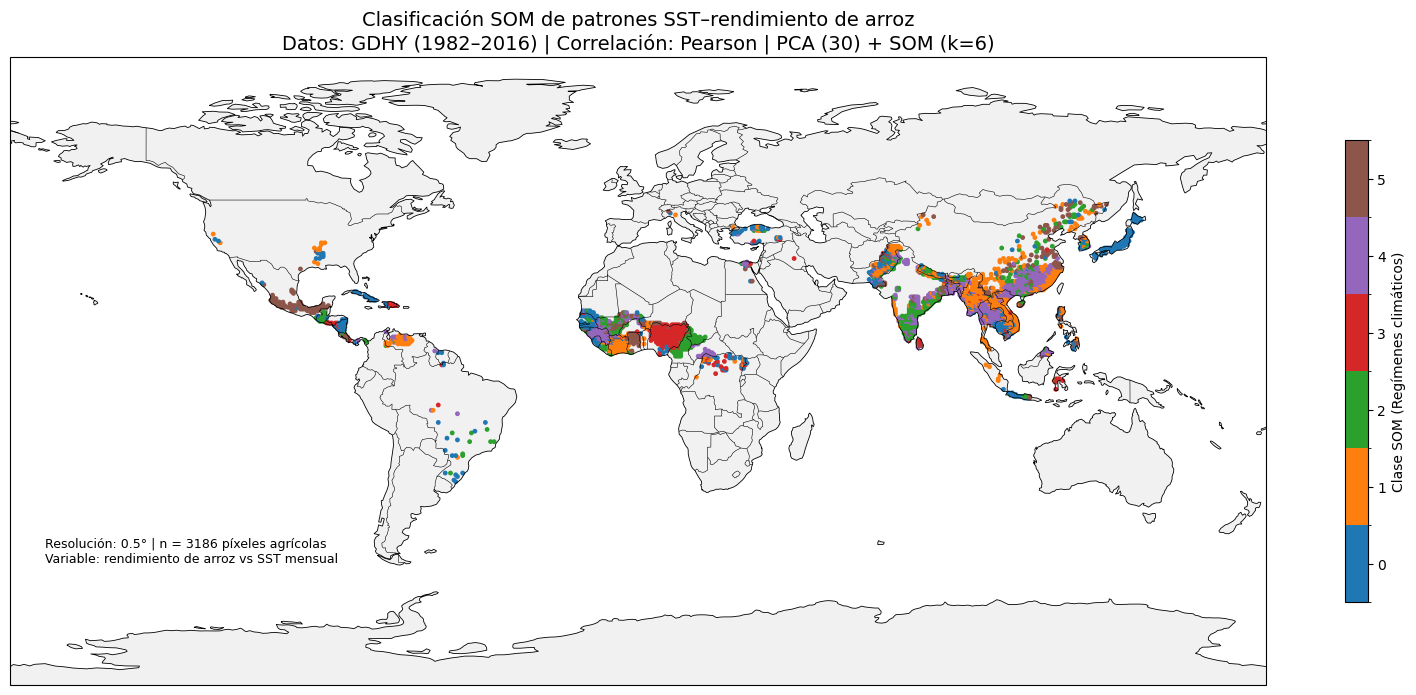

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

# ============================================================
# DATOS
# ============================================================

OUT_DIR = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_som_k6"
df = pd.read_csv(f"{OUT_DIR}\\som_assignments.csv")

lat_idx = df["lat_idx"].values
lon_idx = df["lon_idx"].values
labels  = df["label"].values

# ============================================================
# CONVERSIÓN A LAT/LON
# ============================================================

lat = -89.75 + lat_idx * 0.5
lon = 0.25 + lon_idx * 0.5
lon = np.where(lon > 180, lon - 360, lon)

# ============================================================
# COLORMAP DISCRETO
# ============================================================

colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

# ============================================================
# FIGURA
# ============================================================

fig = plt.figure(figsize=(16,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

# mapa base
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)

# scatter
sc = ax.scatter(
    lon, lat,
    c=labels,
    s=6,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# ============================================================
# TÍTULO PRINCIPAL
# ============================================================

plt.title(
    "Clasificación SOM de patrones SST–rendimiento de arroz\n"
    "Datos: GDHY (1982–2016) | Correlación: Pearson | PCA (30) + SOM (k=6)",
    fontsize=14
)

# ============================================================
# COLORBAR
# ============================================================

cbar = plt.colorbar(sc, ticks=range(6), shrink=0.6)
cbar.set_label("Clase SOM (Regímenes climáticos)")

# ============================================================
# ANOTACIONES (METADATOS)
# ============================================================

plt.text(
    -170, -55,
    "Resolución: 0.5° | n = 3186 píxeles agrícolas\n"
    "Variable: rendimiento de arroz vs SST mensual",
    fontsize=9,
    transform=ccrs.PlateCarree()
)

plt.tight_layout()
plt.show()

In [25]:
import h5py
import numpy as np

file_path = r"C:\Users\paola\Tesis\CORRELA_TODOS\rice_correlacion_vectorizada.h5"

print("=== ABRIENDO ARCHIVO ===\n")

with h5py.File(file_path, "r") as f:

    print("=== ESTRUCTURA GENERAL ===")
    
    def explore(name, obj):
        print(f"\n📦 {name}")
        
        if isinstance(obj, h5py.Dataset):
            print(f"   type      : Dataset")
            print(f"   shape     : {obj.shape}")
            print(f"   dtype     : {obj.dtype}")
            
            # intentar leer muestra pequeña
            try:
                sample = obj[0]
                print(f"   sample shape : {sample.shape if hasattr(sample,'shape') else 'scalar'}")
                
                if np.issubdtype(obj.dtype, np.number):
                    arr = np.array(sample).astype(float)
                    print(f"   sample stats → min: {np.nanmin(arr):.4f}, max: {np.nanmax(arr):.4f}")
            except:
                print("   sample: no se pudo leer")
        
        elif isinstance(obj, h5py.Group):
            print(f"   type      : Group")

    f.visititems(explore)

    print("\n=== ATRIBUTOS DEL ARCHIVO ===")
    for key, val in f.attrs.items():
        print(f"{key}: {val}")

=== ABRIENDO ARCHIVO ===

=== ESTRUCTURA GENERAL ===

📦 correlacion
   type      : Dataset
   shape     : (3186, 12, 259200)
   dtype     : float32
   sample shape : (12, 259200)
   sample stats → min: -0.8172, max: 0.7604

📦 lat_idx
   type      : Dataset
   shape     : (3186,)
   dtype     : int64
   sample shape : ()
   sample stats → min: 116.0000, max: 116.0000

📦 lon_idx
   type      : Dataset
   shape     : (3186,)
   dtype     : int64
   sample shape : ()
   sample stats → min: 615.0000, max: 615.0000

=== ATRIBUTOS DEL ARCHIVO ===
